## Generalized Laplace Active Subspace UQ for the UCI Concrete Compressive Strength test case

Notebook to reproduce the results from section *Regression with unknown observational noise* of

W.N. Edeling, P.V. Coveney, *Scalable Neural Network Uncertainty Quantification via Generalized Laplace
Active Subspaces*, 2026, (submitted).


Missing packages can be installed using e.g.:

In [1]:
#!pip install tqdm

In [2]:
import torch
import torch.nn as nn
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from tqdm import tqdm

# various subroutines we use for the generalized laplace active subspaces, see ./utils/__init__.py
import utils

Here we use the Concrete Compressive Strength dataset from the UCI machine learning repository [1]. This is a regression test case containing $N=1030$ samples and 8 input features describing the concrete mixture, and a scalar output corresponding to compressive strength. We train an overparameterized feed-forward neural network with approximately $D=10^6$ connection weights and use this case to assess the scalability of the proposed matrix-free low-rank generalized Laplace approximation. 

We set the number of training data $N$ to be 90\% of the 1030 available data points. The remainder ($N_{cal}$) is used to calibrate $d$.

[1] I. Yeh, Concrete Compressive Strength. UCI Machine Learning Repository, 1998. DOI: https://doi.org/10.24432/C5PK67.

Fix the random seeds

In [3]:
torch.manual_seed(0)
np.random.seed(0)

### Generate training data

We get the training data from the `ucimlrepo` package. To install this use `!pip install ucimlrepo`

In [4]:
#!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
concrete_compressive_strength = fetch_ucirepo(id=165) 

# data (as pandas dataframes) 
x_pd = concrete_compressive_strength.data.features 
y_pd = concrete_compressive_strength.data.targets 
x_np = x_pd.values
y_np = y_pd.values

# standardize data
x_mean_np = np.mean(x_np, axis=0)
x_std_np = np.std(x_np, axis=0)
y_mean_np = np.mean(y_np, axis=0)
y_std_np = np.std(y_np, axis=0)

y_mean = torch.Tensor(y_mean_np)
y_std = torch.Tensor(y_std_np)

x_np = (x_np - x_mean_np) / x_std_np
y_np = (y_np - y_mean_np) / y_std_np

val_frac = 0.1
N_cal = int(x_np.shape[0] * val_frac)
x_cal_np = x_np[-N_cal:, :]
y_cal_np = y_np[-N_cal:, :]
x_np = x_np[0:-N_cal, :]
y_np = y_np[0:-N_cal, :]

# calibration data
x_cal = torch.tensor(x_cal_np, dtype=torch.float32)
y_cal = torch.tensor(y_cal_np, dtype=torch.float32)

# training data
x = torch.tensor(x_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)
N = x.shape[0]

# variable information 
concrete_compressive_strength.variables

,name,role,type,demographic,description,units,missing_values
0,Cement,Feature,Continuous,None,None,kg/m^3,no
1,Blast Furnace Slag,Feature,Integer,None,None,kg/m^3,no
2,Fly Ash,Feature,Continuous,None,None,kg/m^3,no
3,Water,Feature,Continuous,None,None,kg/m^3,no
4,Superplasticizer,Feature,Continuous,None,None,kg/m^3,no
5,Coarse Aggregate,Feature,Continuous,None,None,kg/m^3,no
6,Fine Aggregate,Feature,Continuous,None,None,kg/m^3,no
7,Age,Feature,Integer,None,None,day,no
8,Concrete compressive strength,Target,Continuous,None,None,MPa,no


The maximium subspace dimension that we consider

In [5]:
d_max = 50

### Create neural network

This creates a very simple feed forward neural network with 2 layers with `n_neurons` neurons per layer

In [6]:
class Net(nn.Module):
    def __init__(self, n_neurons):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_neurons),
            nn.Tanh(),
            nn.Linear(n_neurons, n_neurons),
            nn.Tanh(),
            nn.Linear(n_neurons, 1)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
n_neurons = 1000
n_input = x.shape[1]
model = Net(n_neurons)
# number of connection weights
D = sum([p.numel() for p in model.parameters()])
print(f'There are D = {D} connection weights')

There are D = 1011001 connection weights


### Train neural network

Train the network using standard back propagation techniques, and a **mean** squared loss.

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in range(3000):
    pred = model(x)
    loss = (0.5*(pred - y)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if np.mod(i, 1000) == 0:
        print(f'Loss at iteration {i} = {loss.item():.3e}')

Loss at iteration 0 = 4.796e-01
Loss at iteration 1000 = 4.769e-03
Loss at iteration 2000 = 3.161e-03


In [9]:
model.eval()

Net(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=1000, bias=True)
    (1): Tanh()
    (2): Linear(in_features=1000, out_features=1000, bias=True)
    (3): Tanh()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

### Extract the pretrained weights

In [10]:
# a dictionary containing the weights names and weights tensors
# (without a .clone() small changes can creep in the pretrained weights during sampling)
theta_0_dict = {
    name: p.detach().clone()
    for name, p in model.named_parameters()
}
# all the weights reshaped into a Dx1 tensor
theta_0 = utils.dict_to_vector(theta_0_dict, model).detach().clone()

### Estimate noise from residuals

Since the observation noise is unknown, we estimate the noise $\sigma$ via residuals:

\begin{align}
\sigma^2\approx \frac{1}{N}\sum_{n=1}^{N} \lVert y_n - f(x_n; \theta_0)\rVert_2^2,
\end{align}


In [11]:
with torch.no_grad():
    sigma = ((y - model(x)) ** 2).mean().sqrt().item()
    print(f'sigma = {sigma}')

sigma = 0.07366976886987686


### Choose scaling

The temperature parameter $\beta$ is used to select either the standard Bayesian scaling (related to the summed loss), or the generalized scaling (related to the mean loss).

In [12]:
# beta = 1 / sigma ** 2          # generalized scaling (regression)
beta = N / sigma ** 2        # standard scaling (regression)

# a flag for the type of scaling used: generalized or standard
if beta > 1 / sigma ** 2: scaling = 'std'
else: scaling = 'gen'

### Matrix-free $G$ eigenmodes and comparison

Here we compute the dominant eigenvalues/vectors of $G$ using matrix-free $Gv$ products and the Lanczos algorithm, see Section *Matrix-free computation of dominant eigenpairs*.

In [13]:
m = d_max + 10 
Q, T = utils.lanczos(m, D, model, theta_0_dict, x, N, batch_size = N)
# eigen decomposition of small matrix
eigvals, eigvecs_T = torch.linalg.eigh(T)
# map back to parameter space
eigvecs = Q @ eigvecs_T
# reserve sorting order, which is standard from low to high eigenvalues
eigvals = eigvals.flip(0)
eigvecs = eigvecs.flip(1)

Running Lanczos iterations...


  0%|                                                                                                                                                            | 0/60 [00:00<?, ?it/s]

Computing Gv over 1 batches...


  3%|████▉                                                                                                                                               | 2/60 [00:00<00:10,  5.37it/s]

Computing Gv over 1 batches...
Computing Gv over 1 batches...


...

 97%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████     | 58/60 [00:36<00:02,  1.12s/it]

Computing Gv over 1 batches...


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 59/60 [00:37<00:01,  1.16s/it]

Computing Gv over 1 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:39<00:00,  1.54it/s]


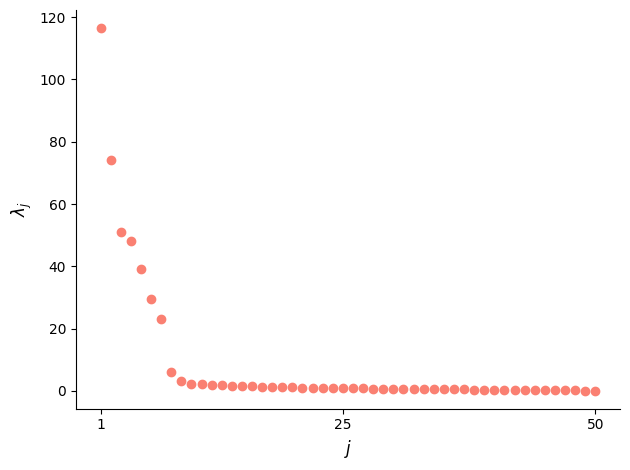

In [14]:
# plot the eigenvalues
with torch.no_grad():
    # plot the d leading eigenvalues
    fig = plt.figure('eigvals')
    ax = fig.add_subplot(111)
    p1 = ax.plot(np.arange(1, d_max+1), eigvals[0:d_max], 'o', color = 'salmon', label='matrix-free')
    ax.set_ylabel(r'$\lambda_j$', fontsize=12)
    ax.set_xlabel(r'$j$', fontsize=12)
    ax.set_xticks([1, int(d_max/2), d_max])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()


### Emprical Bayes for $\sigma_0$ and calibration of $d$

We use an empirical Bayesian procedure to estimate the prior variance $\sigma_0^2$ from the data $y$, see section *"Empirical generalized Bayesian subspace inference for the prior variance"*.

We then loop over $d=1,2,\cdots$, computing $\sigma_0$ at each $d$ by solving:

\begin{align}
\lVert w_0\rVert^2_2 = \sum_{i=1}^d \frac{1}{\alpha} - \frac{1}{\beta\lambda_i + \alpha} = \sum_{i=1}^d \sigma^2_0 - \sigma^2_i,
\end{align}

via the bisection method (`utils.solve_sigma0_lowrank`). We select the first $(d, \sigma_0)$ pair for which the 90% confidence intervals contain at least 90% of the calibration data.

In [15]:
# number of Monte Carlo samples to compute the confidence intervals (CIs)
n_mc = 1000
# nominal CI
target_CI = 0.9
# counter for number of calibration data that fall in the CI
n_frac = 0
# candidate active subspace dimension
d_ = 0
# lists to store coverage vs d
coverage = []
coverage_d = []

# loop until thet required coverage or the maximum subspace dimension is reached
while n_frac < target_CI  and d_ < d_max:
    d_ += 1

    # projected weight norm (||w_0||^2_2)
    theta_0_projected = eigvecs[:, 0:d_].T @ theta_0
    theta_norm_sq_projected = (theta_0_projected**2).sum().item()
    # solve for prior variance 
    sigma0_sq = utils.solve_sigma0_lowrank(eigvals[0:d_], theta_norm_sq_projected, d_, beta)
    sigma_0 = np.sqrt(sigma0_sq)
    # closed form posterior variances
    sigma_sq_post = 1 / (beta * eigvals[0:d_] + 1 / sigma_0 ** 2)
    sigma_post = sigma_sq_post.sqrt()

    # posterior sampling using current d and sigma_0
    samples = torch.zeros([n_mc, N_cal])
    for i in tqdm(range(n_mc)):
        samples[i] = utils.sample(x_cal, model, theta_0, theta_0_dict, sigma_post, eigvecs[:, 0:d_])

    # compute CIs
    lower = torch.quantile(samples, (1 - target_CI) / 2, dim=0)
    upper = torch.quantile(samples, 1/2 + target_CI / 2 , dim=0)

    # check how many calibration data fall within the compute CIs
    with torch.no_grad():
        lower_np = lower.detach().cpu().numpy().flatten()
        upper_np = upper.detach().cpu().numpy().flatten()

        n_inside = 0
        for n in range(N_cal):
            if y_cal_np[n] >= lower_np[n] and y_cal_np[n] <= upper_np[n]:
                n_inside += 1
        n_frac = n_inside / N_cal
        coverage.append(n_frac * 100)
        coverage_d.append(d_)

        print(f'{n_frac * 100:.2f}% of data points fall inside 90% CI for d = {d_}.')

# set the active subspace dimension to d_, recompute
d = d_
print(f'Active subspace dimension d = {d}, prior std. dev. = {sigma_0:.3e}')
with open(f'./data/coverage_{scaling}_bayes.npz', 'wb') as fp:
    np.savez(fp, coverage_d = coverage_d, coverage = coverage)

Converged to root within -5.59e-09
alpha = 63.11279296888862


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 95.91it/s]


9.71% of data points fall inside 90% CI for d = 1.
Converged to root within 1.86e-09
alpha = 124.61450195338949


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 89.10it/s]


11.65% of data points fall inside 90% CI for d = 2.
Converged to root within -9.31e-09
alpha = 127.79809570314076


...

58.25% of data points fall inside 90% CI for d = 48.
Converged to root within 0.00e+00
alpha = 100.33273315645837


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:17<00:00, 55.57it/s]


59.22% of data points fall inside 90% CI for d = 49.
Converged to root within 0.00e+00
alpha = 97.77765655753691


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:16<00:00, 61.97it/s]

61.17% of data points fall inside 90% CI for d = 50.
Active subspace dimension d = 50, prior std. dev. = 1.011e-01


Plot the coverage of the following calibration steps as a function of $d$:

* Standard scaling + sampled Laplace
* Generalized scaling + sampled Laplace

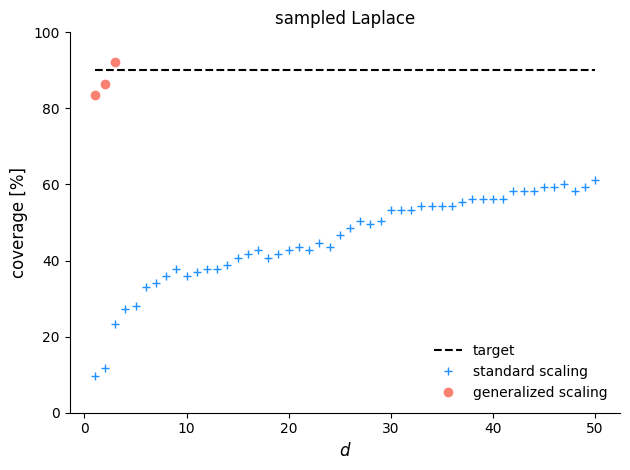

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111, ylim = [0, 100], title=r'sampled Laplace')
coverage_std = np.load('./data/coverage_std_bayes.npz')
coverage_gen = np.load('./data/coverage_gen_bayes.npz')
coverage_std_lin = np.load('./data/coverage_std_bayes_lin.npz')
ax.plot(coverage_std['coverage_d'], np.ones(len(coverage_std['coverage_d'])) * target_CI * 100, '--k', label='target')
ax.plot(coverage_std['coverage_d'], coverage_std['coverage'],\
        '+', color ='dodgerblue', label='standard scaling')
ax.plot(coverage_gen['coverage_d'], coverage_gen['coverage'],\
        'o', color ='salmon', label='generalized scaling')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r'$d$', fontsize=12)
ax.set_ylabel(r'coverage [%]', fontsize=12)
plt.legend(loc=0, frameon=False, draggable=True)
plt.tight_layout()
plt.savefig('./images/coverage.png', dpi=300)

### Contraction ratio

Plot the contraction ratio for the first `d_max` dominant directions of the $G$ eigenspace:

\begin{align}
c_i := \frac{\beta \lambda_i}{ \beta \lambda_i + \frac{1}{\sigma^2_0}},
\end{align}

for which $c_i = 1$ implies that the $i$-th direction is strongly data-informed, and values close to zero denote prior-dominated directions.

In the same figure we plot the posterior variance $\sigma_j^2$.

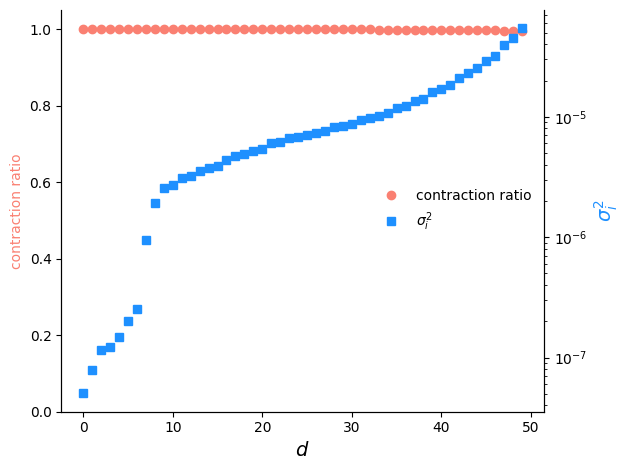

In [17]:
with torch.no_grad():
    eigvals_np = eigvals.cpu().numpy().flatten()
    contraction_ratio = beta * eigvals_np / (beta * eigvals_np + 1 / sigma_0 ** 2)
    var_post = 1 / (beta * eigvals_np + 1 / sigma_0 ** 2)

    fig = plt.figure()
    ax = fig.add_subplot(111, ylim=[0,1.05])
    p1 = ax.plot(contraction_ratio[0:d_max], 'o', color = 'salmon', label='contraction ratio')
    ax.set_xlabel(r'$d$', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('contraction ratio', color='salmon')
    
    ax2 = ax.twinx()
    p2 = ax2.plot(var_post[0:d_max], 's', color = 'dodgerblue', label=r'$\sigma^2_i$')
    ax2.spines['top'].set_visible(False)
    ax2.set_yscale('log')
    ax2.set_ylabel(r'$\sigma^2_i$', color='dodgerblue', fontsize=14)
    
    lns = p1 + p2
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=5, frameon=False, draggable=True)

    plt.tight_layout()

In [18]:
# # set the final eigenvalues/vectors
# sigma_post = sigma_post[0:d]
# eigvecs = eigvecs[:, 0:d]

### Confindence interval plot

Recreate the confidence interval plots. Since the input features are multivariate, we do not plot $f(x)$ versus $x$. Instead we make a parity plot, where we display the mean predicted compressive strength versus itself with 90\% CIs, and the mean predicted compressive strength versus the calibration data.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:17<00:00, 57.77it/s]


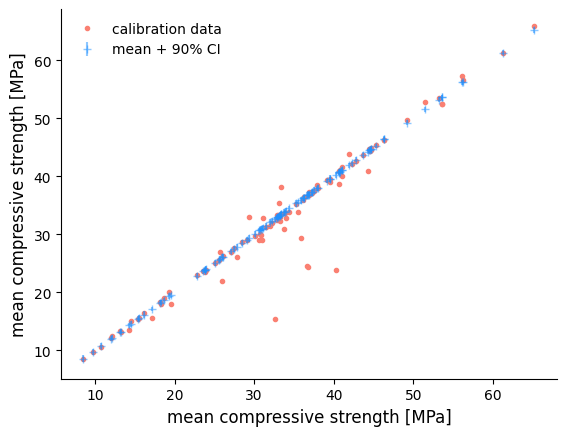

In [31]:
# posterior sampling
n_mc = 1000
samples = torch.zeros([n_mc, N_cal])
for i in tqdm(range(n_mc)):
    samples[i] = utils.sample(x_cal, model, theta_0, theta_0_dict, sigma_post[0:d], eigvecs[:, 0:d])
samples = samples * y_std + y_mean

# mean and CIs
mean = samples.mean(dim=0)
lower = torch.quantile(samples, (1 - target_CI) / 2, dim=0)
upper = torch.quantile(samples, 1/2 + target_CI / 2 , dim=0)

with torch.no_grad():

    mean_np = mean.detach().cpu().numpy().flatten()
    lower_np = lower.detach().cpu().numpy().flatten()
    upper_np = upper.detach().cpu().numpy().flatten()

    cal_data = y_cal_np.flatten() * y_std_np + y_mean_np

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(mean_np, cal_data, '.', color='salmon', label=r'calibration data')
    ax.errorbar(mean_np, mean_np, yerr = [upper_np - mean_np, 
                                          mean_np - lower_np],
                color = 'dodgerblue', fmt = '+', label=f'mean + {int(target_CI * 100)}% CI',
                alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 

    ax.set_xlabel(r'mean compressive strength [MPa]', fontsize=12)
    ax.set_ylabel(r'mean compressive strength [MPa]', fontsize=12)
    plt.legend(loc=0, frameon=False)
    fig.savefig(f'./images/f_concrete_{scaling}_bayes.png', dpi=300)

### Activity scores

Activity scoresare (first-order) sensitivity indices for individual parameters, which can be extracted from the active subspace eigenmodes. Analogously, using the $G$ eigenmodes, we define the activity scores for individual connection weights as:

\begin{align}
    \nu_i = \sum_{j=1}^d \lambda_j p_{j, i}^2, \quad i=1,\cdots,D.
\end{align}

Here $p_{j, i}$ is the $i$-th component of the $j$-th eigenvector of $G$.

However, rather than plotting individual $\nu_i$, we first sort from largest to smallest and instead plot the cumulative scores

\begin{align}
    \kappa_i = \frac{\sum_{j=1}^i \nu_j}{\sum_{j=1}^D \nu_j},\quad i=1,\cdots,D,
\end{align}

in a log-log plot.

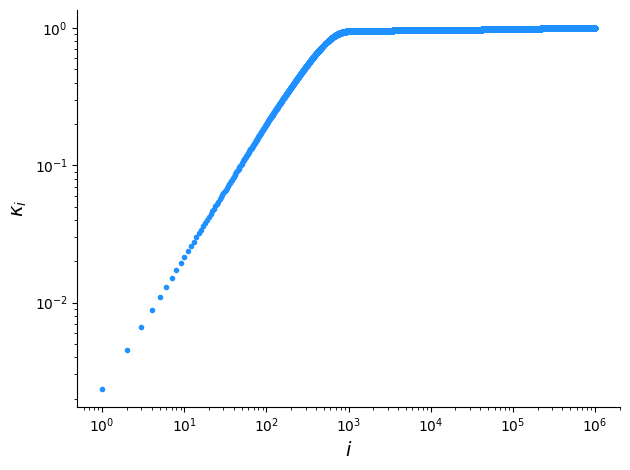

In [20]:
with torch.no_grad():

    # activity scores
    nu = 0.
    for j in range(d):
        nu += eigvals[j] * eigvecs[:, j] ** 2
    nu = np.sort(nu.numpy())[::-1]
    kappa_i = np.cumsum(nu)/np.sum(nu)

    # plot all D cumulative (normalised) activity scores
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(np.arange(1, D+1), kappa_i, '.', color='dodgerblue')   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(r'$\kappa_i$', fontsize=14)
    ax.set_xlabel(r'$i$', fontsize=14)  
    plt.xscale('log')
    plt.yscale('log')
    plt.tight_layout()
    fig.savefig('./images/activity_scores_concrete.png', dpi=300)

In [21]:
i = np.where(kappa_i > 0.95)[0][0]
print(f'The first {i / D * 100:.1f}% of the connection weights account for 95% of the curvature energy.')

The first 0.1% of the connection weights account for 95% of the curvature energy.


### Linear Laplace

Linearized Laplace makes the a local linear approximation in the predictive model, keeping the posterior predictive mean fixed at the MAP prediction:

\begin{align}
    f(x;\theta) \approx f_{lin}(x; \theta) = f(x;\theta_0) + J(x)\left(\theta - \theta_0\right),
\end{align}

where $J(x):=\nabla_\theta f(x;\theta_0)\in\mathbb{R}^{M\times D}$. The combination of the linear output and the Gaussian distribution of $\theta$ also leads a closed-form predictive covariance $\Sigma_f=J\Sigma J^T$, where $\Sigma=P\Lambda P^T$, with $\Lambda:=\mathrm{diag}(\sigma^2_j)$ is our low-rank Laplace posterior covariance. In the case of scalar regression the (pointwise) posterior predictive variance becomes

\begin{align}
    \sigma^2_f(x) = \sum_{j=1}^d \sigma^2_j \left(J(x) p_j\right)^2\in\mathbb{R},
\end{align}
with $p_j\in\mathbb{R}^D$ denoting the j-th eigenvector of $P$, $P$ being the $D\times d$ projection matrix consisting of dominant eigenvectors of $G$.

Below we repeat the calibration procedure, except instead of sampling the nonlinear model, we now use $f(x;\theta_0)\pm 2\sigma_f$ as a 95% confidence interval. If this CI is not able to capture 95% of the calibration data, the algorithm will stop once $d=50$ is reached.

In [22]:
# nominal CI
target_CI = 0.95
# counter for number of calibration data that fall in the CI
n_frac = 0
# candidate active subspace dimension
d_ = 0
# lists to store coverage vs d
coverage = []
coverage_d = []

# loop until thet required coverage or the maximum subspace dimension is reached
while n_frac < target_CI  and d_ < d_max:
    d_ += 1

    # projected weight norm (||w_0||^2_2)
    theta_0_projected = eigvecs[:, 0:d_].T @ theta_0
    theta_norm_sq_projected = (theta_0_projected ** 2).sum().item()
    # solve for prior variance 
    sigma0_sq = utils.solve_sigma0_lowrank(eigvals[0:d_], theta_norm_sq_projected, d_, beta)
    sigma_0 = np.sqrt(sigma0_sq)
    # closed form posterior variances
    sigma_sq_post = 1 / (beta * eigvals[0:d_] + 1 / sigma_0 ** 2)
    sigma_post = sigma_sq_post.sqrt()

    # posterior linear Laplace using current d and sigma_0
    mean_f, std_f = utils.linear_laplace(x_cal, model, theta_0_dict, eigvecs, sigma_post, d_)

    # compute CIs
    lower = mean_f - 2 * std_f
    upper = mean_f + 2 * std_f

    # check how many calibration data fall within the compute CIs
    with torch.no_grad():

        lower_np = lower.detach().cpu().numpy().flatten()
        upper_np = upper.detach().cpu().numpy().flatten()

        n_inside = 0
        for n in range(N_cal):
            if y_cal_np[n] >= lower_np[n] and y_cal_np[n] <= upper_np[n]:
                n_inside += 1
        n_frac = n_inside / N_cal
        print(f'{n_frac * 100}% of data points fall inside 95% CI for d = {d_}.')
        coverage.append(n_frac * 100)
        coverage_d.append(d_)

# set the active subspace dimension to d_, recompute
d = d_
print(f'Active subspace dimension d = {d}, prior std. dev. = {sigma_0:.3e}')
with open(f'./data/coverage_{scaling}_bayes_lin.npz', 'wb') as fp:
    np.savez(fp, coverage_d = coverage_d, coverage = coverage)

Converged to root within -5.59e-09
alpha = 63.11279296888862
10.679611650485436% of data points fall inside 95% CI for d = 1.
Converged to root within 1.86e-09
alpha = 124.61450195338949
16.50485436893204% of data points fall inside 95% CI for d = 2.
Converged to root within -9.31e-09
alpha = 127.79809570314076
30.097087378640776% of data points fall inside 95% CI for d = 3.
Converged to root within -3.73e-09
alpha = 144.34497070748654
32.038834951456316% of data points fall inside 95% CI for d = 4.
Converged to root within -3.73e-09
alpha = 130.6768798877079
34.95145631067961% of data points fall inside 95% CI for d = 5.
Converged to root within 7.45e-09
alpha = 137.66442871556
36.89320388349515% of data points fall inside 95% CI for d = 6.
Converged to root within 7.45e-09
alpha = 138.80401611785925
39.80582524271845% of data points fall inside 95% CI for d = 7.
Converged to root within 0.00e+00
alpha = 157.5068359413474
41.74757281553398% of data points fall inside 95% CI for d = 8.

Plot the coverage of the following calibration steps as a function of $d$:

* Standard scaling + linear Laplace
* Generalized scaling + linear Laplace

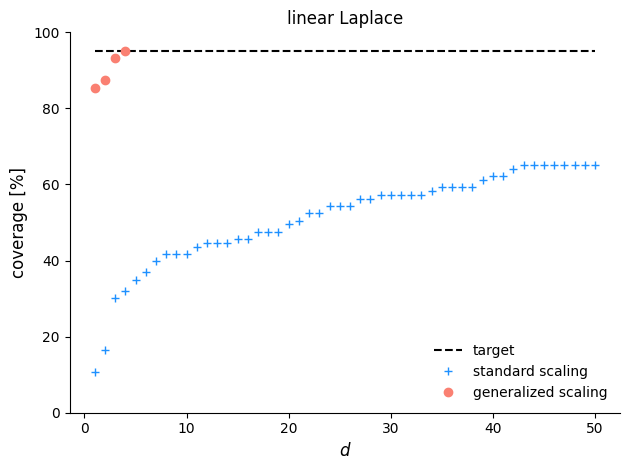

In [23]:
fig = plt.figure('coverage_vs_d')
ax = fig.add_subplot(111, ylim = [0, 100], title=r'linear Laplace')
coverage_std_lin = np.load('./data/coverage_std_bayes_lin.npz')
coverage_gen_lin = np.load('./data/coverage_gen_bayes_lin.npz')
ax.plot(coverage_std_lin['coverage_d'], np.ones(len(coverage_std_lin['coverage_d'])) * target_CI * 100, '--k', label='target')
ax.plot(coverage_std_lin['coverage_d'], coverage_std_lin['coverage'],\
        '+', color ='dodgerblue', label='standard scaling')
ax.plot(coverage_gen_lin['coverage_d'], coverage_gen_lin['coverage'],\
        'o', color ='salmon', label='generalized scaling')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r'$d$', fontsize=12)
ax.set_ylabel(r'coverage [%]', fontsize=12)
plt.legend(loc=0, frameon=False, draggable=True)
plt.tight_layout()
plt.savefig('./images/coverage_lin.png', dpi=300)